**Author**: Felipe Matheus  
**Start Date**: 06/05/2026  
**End Date**: --/--/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from src.modeling.Evaluation import Evaluation
from config.Variables import Variables

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [34]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
mdl = Modeling()
evl = Evaluation()
varv = Variables()

## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [3]:
# ---- Experiment settings ----
TAG = "full-features_no-weight_test1"
SCHEMA_DATE = "080626"

# ---- Paths ----
PATH_DATA_RAW = "../../data/raw"
PATH_MODELS = "../../models"
FILE_NAME = "dataset_annealing_iacs.csv"
FILE_NAME_SCHEMA_DATA = "schema_annealing_essays_{}.csv".format(SCHEMA_DATE)
PROCESS = "annealing_iacs"

# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(PATH_MODELS, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "iacs_final"
FEATURES = ["purity", "iacs", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "medium_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of sigma2_aleat as fraction of Var(y)
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
USE_SHARED_FOLDS = True           # same fold_id column on both engines
FOLD_SEED = 42

# ---- Physical constraints (inference-time) ----
Y_MAX = 106.0                     # physical ceiling for %IACS


# 2. Data

## 2.1 Schema data

In [4]:
# Schema dataset. Mark essay rows EXPLICITLY (used later for weight_col).
df_raw_schema = pd.read_csv(os.path.join(PATH_DATA_RAW, FILE_NAME_SCHEMA_DATA))
df_schema = df_raw_schema[FEATURES + [TARGET]].dropna()
df_schema["is_essay"] = True
df_schema


,purity,iacs,temperature,time,iacs_final,is_essay
0,99.9,88.260,623.0,30.0,88.350000,True
1,99.9,88.260,623.0,60.0,88.655000,True
2,99.9,88.260,623.0,90.0,88.800000,True
3,99.9,99.825,573.0,30.0,102.340000,True
4,99.9,99.390,573.0,30.0,102.230000,True
5,99.9,99.390,588.0,30.0,101.346667,True
6,99.9,99.230,573.0,30.0,101.355000,True
7,99.9,98.720,573.0,30.0,101.480000,True
17,99.9,100.250,573.0,30.0,102.755000,True


## 2.2 Literature data

In [5]:
# Raw CSV.
df_raw = pd.read_csv(os.path.join(PATH_DATA_RAW, FILE_NAME))
df_raw.head()

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final
0,Cu,99.98,320,97,473,30,~500,100
1,Cu,99.98,320,97,523,600,~800,100
2,Cu,99.98,320,97,573,120,~900,103
3,Cu,99.98,320,96,473,30,~500,99
4,Cu,99.98,320,95,523,600,~800,98


In [6]:
# Cast to float, label material elements, mark rows where ratios are valid.
df_float = proc.df_to_float(
    df_raw, drop_cols=["DOI"], ignore_columns=["material"]
)
df_labeled = feng.label_element(df_float).drop_duplicates()
df_with_masks = feng.add_ratio_mask_column(
    feng.add_ratio_mask_column(df_labeled, "grain_size"),
    "iacs",
)

# Keep only copper rows and the schema columns.
mask_cu = df_with_masks.has_Cu == True
df_lit = df_with_masks[mask_cu]
df_lit = df_lit[FEATURES + [TARGET]]
df_lit["is_essay"] = False

assert df_lit[FEATURES + [TARGET]].isna().sum().sum() == 0, "NaNs in inputs"
print(f"Dataset: {df_lit.shape}")
df_lit.head()


Dataset: (87, 6)


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(


,purity,iacs,temperature,time,iacs_final,is_essay
0,99.98,97.0,473.0,30.0,100.0,False
1,99.98,97.0,523.0,600.0,100.0,False
2,99.98,97.0,573.0,120.0,103.0,False
3,99.98,96.0,473.0,30.0,99.0,False
4,99.98,95.0,523.0,600.0,98.0,False


## 2.3 Concat dataset

In [7]:
df = pd.concat([df_schema, df_lit], ignore_index=True)

# weight_col built from the explicit is_essay marker.
# (The old positional `df.loc[: len(df_raw_schema)]` was buggy: .loc slices
# are inclusive AND df_schema shrinks after dropna, so literature rows could
# silently receive the essay weight.)
df["weight_col"] = np.where(df["is_essay"], WEIGHT_ON_ESSAY_ROWS, 1.0)

# Optional shared fold column: the SAME partition is passed to AutoGluon
# (groups=) and H2O (fold_column=) so OOF comparisons use identical folds.
if USE_SHARED_FOLDS:
    from sklearn.model_selection import KFold
    df["fold_id"] = -1
    splitter = KFold(
        n_splits=NUM_BAG_FOLDS_A, shuffle=True, random_state=FOLD_SEED
    )
    for k, (_, test_idx) in enumerate(splitter.split(df)):
        df.iloc[test_idx, df.columns.get_loc("fold_id")] = k

df


,purity,iacs,temperature,time,iacs_final,is_essay,weight_col,fold_id
0,99.9,88.260,623.0,30.0,88.350,True,1.0,0
1,99.9,88.260,623.0,60.0,88.655,True,1.0,4
2,99.9,88.260,623.0,90.0,88.800,True,1.0,4
3,99.9,99.825,573.0,30.0,102.340,True,1.0,2
4,99.9,99.390,573.0,30.0,102.230,True,1.0,0
...,...,...,...,...,...,...,...,...
91,99.0,88.000,673.0,30.0,97.000,False,1.0,2
92,99.0,87.000,473.0,30.0,89.000,False,1.0,4
93,99.0,87.000,573.0,30.0,92.000,False,1.0,3
94,99.0,87.000,673.0,30.0,95.000,False,1.0,0


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [8]:
df

,purity,iacs,temperature,time,iacs_final,is_essay,weight_col,fold_id
0,99.9,88.260,623.0,30.0,88.350,True,1.0,0
1,99.9,88.260,623.0,60.0,88.655,True,1.0,4
2,99.9,88.260,623.0,90.0,88.800,True,1.0,4
3,99.9,99.825,573.0,30.0,102.340,True,1.0,2
4,99.9,99.390,573.0,30.0,102.230,True,1.0,0
...,...,...,...,...,...,...,...,...
91,99.0,88.000,673.0,30.0,97.000,False,1.0,2
92,99.0,87.000,473.0,30.0,89.000,False,1.0,4
93,99.0,87.000,573.0,30.0,92.000,False,1.0,3
94,99.0,87.000,673.0,30.0,95.000,False,1.0,0


In [10]:
predictor_a = mdl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    groups="fold_id" if USE_SHARED_FOLDS else None,
    sample_weight="weight_col",
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       9.64 GB / 31.57 GB (30.5%)
Disk Space Avail:   753.21 GB / 932.08 GB (80.8%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Values in column 'weight_col' used as sample weights instead of predictive features. Evaluation metrics will ignore sample weights, specify weight_evaluation=True to instead report weighted metrics.
Values in column 'fold_id' used as split folds instead of being automatically set. Bagged models will have 5 splits.
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\full-features_no-wei

In [11]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-3.687233,root_mean_squared_error,0.124287,56.404983,0.000000,0.008547,2,True,10
1,CatBoost_BAG_L1,-3.865377,root_mean_squared_error,0.017733,38.370212,0.017733,38.370212,1,True,4
2,NeuralNetTorch_BAG_L1,-4.076030,root_mean_squared_error,0.038450,9.030768,0.038450,9.030768,1,True,8
3,XGBoost_BAG_L1,-4.389967,root_mean_squared_error,0.018420,1.080844,0.018420,1.080844,1,True,7
4,ExtraTreesMSE_BAG_L1,-4.611987,root_mean_squared_error,0.237288,1.482342,0.237288,1.482342,1,True,5
5,LightGBMLarge_BAG_L1,-4.860725,root_mean_squared_error,0.001840,1.120529,0.001840,1.120529,1,True,9
6,RandomForestMSE_BAG_L1,-5.019988,root_mean_squared_error,0.204293,1.287667,0.204293,1.287667,1,True,3
7,NeuralNetFastAI_BAG_L1,-5.144189,root_mean_squared_error,0.049684,7.914611,0.049684,7.914611,1,True,6
8,LightGBM_BAG_L1,-6.426811,root_mean_squared_error,0.009330,1.001545,0.009330,1.001545,1,True,2
9,LightGBMXT_BAG_L1,-6.850915,root_mean_squared_error,0.017070,1.002168,0.017070,1.002168,1,True,1


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [12]:
import h2o
from h2o.automl import H2OAutoML

h2o.init(nthreads=-1, max_mem_size="4G")

h2o_cols = FEATURES + [TARGET, "weight_col"]
if USE_SHARED_FOLDS:
    h2o_cols.append("fold_id")
train_h2o = h2o.H2OFrame(df[h2o_cols])
train_h2o[TARGET] = train_h2o[TARGET].asnumeric()
if USE_SHARED_FOLDS:
    # fold_column must be categorical on the H2O side.
    train_h2o["fold_id"] = train_h2o["fold_id"].asfactor()

aml_kwargs = dict(
    max_runtime_secs=TIME_LIMIT_A,
    keep_cross_validation_predictions=True,
    sort_metric="RMSE",
    seed=42,
)
if not USE_SHARED_FOLDS:
    aml_kwargs["nfolds"] = NUM_BAG_FOLDS_A  # nfolds is ignored/conflicting with fold_column

aml_h2o = H2OAutoML(**aml_kwargs)

train_kwargs = dict(x=FEATURES, y=TARGET, training_frame=train_h2o,
                    weights_column="weight_col")
if USE_SHARED_FOLDS:
    train_kwargs["fold_column"] = "fold_id"

aml_h2o.train(**train_kwargs)

aml_h2o.leaderboard.head(10)


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 24.0.2+12-54, mixed mode, sharing)
  Starting server from C:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\fmfoa\AppData\Local\Temp\tmpbdqzhjnk
  JVM stdout: C:\Users\fmfoa\AppData\Local\Temp\tmpbdqzhjnk\h2o_fmfoa_started_from_python.out
  JVM stderr: C:\Users\fmfoa\AppData\Local\Temp\tmpbdqzhjnk\h2o_fmfoa_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,3 months
H2O_cluster_name:,H2O_from_python_fmfoa_7pehvm
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.983 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
13:09:14.196: Fold column fold_id will be used for cross-validation. nfolds parameter will be ignored.
13:09:14.203: AutoML: XGBoost is not available; skipping it.


13:09:14.605: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 96.0.

█
13:09:15.741: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the meta learner, please specify it as an argument in the h2o.stackedEnsemble call.
13:09:15.874: _weights_column param, All base models use weights_column="weight_col" but Stacked Ensemble does not. If you want to use the same weights_column for the meta learner, please specify it as an argument in the h2o.stackedEnsemble call.

█████████
13:09:17.761: _weights_column param, All base models use wei

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_grid_1_AutoML_1_20260612_130914_model_64,3.7758,14.2567,2.11159,0.0480743,14.2567
StackedEnsemble_BestOfFamily_3_AutoML_1_20260612_130914,3.99846,15.9877,2.20367,0.0508097,15.9877
GBM_grid_1_AutoML_1_20260612_130914_model_590,4.01874,16.1503,2.61111,0.0507718,16.1503
GBM_grid_1_AutoML_1_20260612_130914_model_412,4.13213,17.0745,2.56101,0.0527035,17.0745
GBM_grid_1_AutoML_1_20260612_130914_model_55,4.17064,17.3943,2.65989,0.0529927,17.3943
GBM_5_AutoML_1_20260612_130914,4.20921,17.7174,2.57066,0.0538339,17.7174
GBM_grid_1_AutoML_1_20260612_130914_model_51,4.21403,17.7581,2.64698,0.0537391,17.7581
StackedEnsemble_AllModels_4_AutoML_1_20260612_130914,4.23478,17.9333,2.75935,0.0562429,17.9333
GBM_grid_1_AutoML_1_20260612_130914_model_123,4.23789,17.9597,2.69804,0.0544251,17.9597
StackedEnsemble_AllModels_3_AutoML_1_20260612_130914,4.2626,18.1698,2.79678,0.0564459,18.1698


In [13]:
# NOTE: the previous cell here compared AutoGluon's `score_val` against
# H2O's xval RMSE. That comparison is incoherent when sample weights are
# active: H2O's xval RMSE is WEIGHTED by weights_column, while AutoGluon's
# score_val is UNWEIGHTED unless weight_evaluation=True. The fair,
# like-for-like comparison (unweighted metrics on OOF predictions of both
# engines, same y_true, same folds when USE_SHARED_FOLDS) is done in
# Section 10 ("OOF metrics: AutoGluon vs H2O").
print("See Section 10 for the coherent OOF-vs-OOF comparison.")


See Section 10 for the coherent OOF-vs-OOF comparison.


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [14]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = df[TARGET] - mu_oof
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(96,)  any NaN? False


In [15]:
mu_oof

0      93.369926
1      93.448517
2      94.144073
3     102.145912
4     101.771553
         ...    
91     95.141022
92     88.268921
93     91.229393
94     95.544464
95     92.473869
Name: iacs_final, Length: 96, dtype: float32

In [16]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = mdl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (9, 96)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1']


In [17]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = mdl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000004  (OK)

Non-zero weights:
  CatBoost_BAG_L1                 0.4211
  NeuralNetFastAI_BAG_L1          0.1053
  XGBoost_BAG_L1                  0.1053
  NeuralNetTorch_BAG_L1           0.3684


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [18]:
mu_recomputed, sigma2_epist_oof = mdl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

print("sigma2_epist_oof stats:")
print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
print(f"  median = {np.median(sigma2_epist_oof):.4f}")
print(f"  max    = {sigma2_epist_oof.max():.4f}")

sigma2_epist_oof stats:
  mean   = 3.6304
  median = 0.9885
  max    = 45.3684


In [19]:
mu_oof

0      93.369926
1      93.448517
2      94.144073
3     102.145912
4     101.771553
         ...    
91     95.141022
92     88.268921
93     91.229393
94     95.544464
95     92.473869
Name: iacs_final, Length: 96, dtype: float32

In [20]:
mu_recomputed

array([ 93.3699247 ,  93.44851881,  94.14407661, 102.14591179,
       101.77155504, 102.03171022, 101.83467832, 101.73315356,
       102.27959088,  99.38286197, 101.3746228 ,  97.38430454,
        98.45245103,  97.47614583,  97.47310194,  96.41928752,
        72.73498245,  83.23352073,  76.82175111,  75.36413075,
        78.36775193,  79.66777543,  84.46822229,  87.79973291,
        82.25081415,  71.4206261 ,  75.24338103,  83.68254397,
        85.17872023,  82.49606923,  82.78515526,  84.83281325,
        79.52680842,  87.33587183,  89.59380867,  70.12196038,
        73.65190217,  80.10353672,  56.01348919,  56.80072528,
        58.07252216,  60.06314953,  98.91798742, 100.9702043 ,
       100.35407216, 101.81088863, 100.78640327, 102.41092244,
       101.75304917, 102.70115768, 102.32183552, 102.82512877,
        94.79403696,  97.78811176,  97.6185456 ,  94.0990713 ,
        95.72012128,  96.6225981 ,  92.23963344,  94.09549167,
        97.14208428,  90.27770833,  92.96809913,  95.15

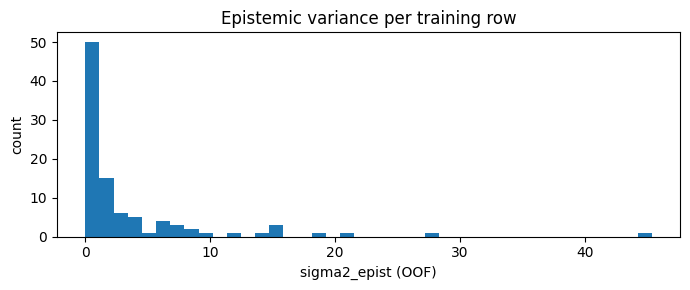

In [21]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

sigma2_epist_oof stats:
  mean   = 7.9082
  median = 3.0169
  max    = 80.4146


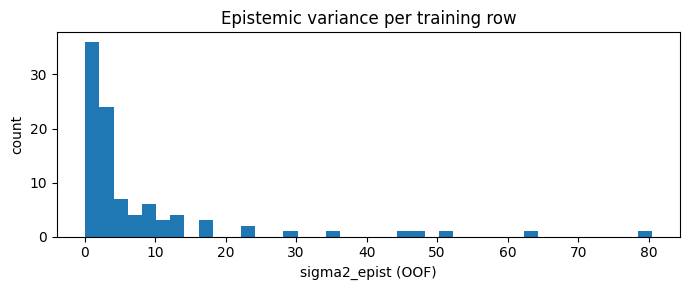

In [22]:
mu_recomputed_lin, sigma2_epist_oof_lin = mdl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

print("sigma2_epist_oof stats:")
print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [23]:
r_tilde_sq, residuals_oof_arr, diag = mdl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 96
  n_truncated          = 44
  pct_truncated        = 45.833333333333336
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 262.49838685897873
  r_tilde_sq_mean      = 10.7318332792998
  r_tilde_sq_median    = 0.22922946210117884


# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [24]:
predictor_b = mdl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       6.83 GB / 31.57 GB (21.6%)
Disk Space Avail:   753.04 GB / 932.08 GB (80.8%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\full-features_no-weight_test1\model_b"
Train Data Rows:    96
Train Data Columns: 4
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (5.570244940523215, -13.815510557964274, -

In [25]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-6.740000,root_mean_squared_error,0.090549,9.695050,0.000999,0.007997,2,True,10
1,LightGBM_BAG_L1,-7.050429,root_mean_squared_error,0.004010,1.390052,0.004010,1.390052,1,True,2
2,XGBoost_BAG_L1,-7.075084,root_mean_squared_error,0.015976,0.795575,0.015976,0.795575,1,True,7
3,CatBoost_BAG_L1,-7.197934,root_mean_squared_error,0.005015,1.982781,0.005015,1.982781,1,True,4
4,LightGBMXT_BAG_L1,-7.207491,root_mean_squared_error,0.006999,1.512410,0.006999,1.512410,1,True,1
5,NeuralNetFastAI_BAG_L1,-7.234478,root_mean_squared_error,0.033042,7.047319,0.033042,7.047319,1,True,6
6,ExtraTreesMSE_BAG_L1,-7.236675,root_mean_squared_error,0.036522,0.454107,0.036522,0.454107,1,True,5
7,LightGBMLarge_BAG_L1,-7.262304,root_mean_squared_error,0.004013,1.067225,0.004013,1.067225,1,True,9
8,RandomForestMSE_BAG_L1,-7.328463,root_mean_squared_error,0.038342,0.494171,0.038342,0.494171,1,True,3
9,NeuralNetTorch_BAG_L1,-7.843483,root_mean_squared_error,0.024925,6.124881,0.024925,6.124881,1,True,8


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [26]:
# Build the full OOF predictive distribution.
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = mdl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = mdl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
print(cal_before)

=== Calibration BEFORE recalibration ===
   alpha  empirical_coverage       gap
0   0.50            0.510417  0.010417
1   0.80            0.781250 -0.018750
2   0.90            0.833333 -0.066667
3   0.95            0.906250 -0.043750


In [27]:
# Fit a scalar recalibration factor to pull coverage at α=0.9 to nominal.
c_opt = mdl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = mdl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
print(cal_after)

Recalibration scalar c = 1.1411

=== Calibration AFTER recalibration ===
   alpha  empirical_coverage       gap
0   0.50            0.562500  0.062500
1   0.80            0.822917  0.022917
2   0.90            0.895833 -0.004167
3   0.95            0.916667 -0.033333


# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [28]:
df.head(5)

,purity,iacs,temperature,time,iacs_final,is_essay,weight_col,fold_id
0,99.9,88.260,623.0,30.0,88.350,True,1.0,0
1,99.9,88.260,623.0,60.0,88.655,True,1.0,4
2,99.9,88.260,623.0,90.0,88.800,True,1.0,4
3,99.9,99.825,573.0,30.0,102.340,True,1.0,2
4,99.9,99.390,573.0,30.0,102.230,True,1.0,0


In [29]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = mdl.fit_ood_reference(df, features=FEATURES)

preds = mdl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,          # physical ceiling -> mu_trunc / sigma_trunc / p_above_max
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds


,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,92.017598,13.226862,1.411706,19.059614,4.365732,92.017601,1.0,92.007275,4.349156,6.805811e-04
1,92.440172,11.365696,1.411706,16.636351,4.078768,92.440170,1.0,92.433690,4.067975,4.429005e-04
2,91.042855,3.141796,1.411706,5.928721,2.434897,91.042854,1.0,91.042855,2.434897,4.053318e-10
3,102.127986,0.100848,1.411706,1.969366,1.403341,102.127983,1.0,102.115506,1.385961,2.897690e-03
4,101.882288,0.069619,1.411706,1.928706,1.388778,101.882286,1.0,101.875445,1.378580,1.513472e-03


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [30]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "y_max": Y_MAX,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")


Saved to: ../../models\annealing_iacs\full-features_no-weight_test1\artifacts.pkl


In [31]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "SCHEMA_DATE": SCHEMA_DATE,
    "PATH_DATA_RAW": PATH_DATA_RAW,
    "PATH_MODELS": PATH_MODELS,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
    "Y_MAX": Y_MAX,
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")


Saved to: ../../models\annealing_iacs\full-features_no-weight_test1\global_config.txt


In [33]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
h2o_oof_preds = (
    aml_h2o.leader.cross_validation_holdout_predictions()
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_agl = evl.one_step_metrics(y_true=y_true, mu=mu_oof.values)
metrics_h2o = evl.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")


                         model      rmse       mae      mape        r2
0  AutoGluon (Model A, leader)  3.687233  2.165563  2.712129  0.902679
1          H2O AutoML (leader)  3.775803  2.111591  2.639929  0.897948
Saved to: ../../models\annealing_iacs\full-features_no-weight_test1


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
